1.Data Preprocessing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

# Load dataset (Example: Metro_Interstate_Traffic_Volume.csv)
df = pd.read_csv('/content/drive/MyDrive/8th semester/Neural Network Lab/Metro_Interstate_Traffic_Volume.csv')
data = df['traffic_volume'].values.reshape(-1, 1)

# Normalize data (0 to 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences (Sliding Window: 50 time steps)
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 50
X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Train/Test Split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

2.RNN model

In [4]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_history = rnn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0143 - val_loss: 0.0072
Epoch 2/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0098 - val_loss: 0.0074
Epoch 3/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0094 - val_loss: 0.0060
Epoch 4/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0088 - val_loss: 0.0059
Epoch 5/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0086 - val_loss: 0.0057
Epoch 6/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0083 - val_loss: 0.0057
Epoch 7/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0082 - val_loss: 0.0056
Epoch 8/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0081 - val_loss: 0.0057
Epoch 9/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0079 - val_loss: 0.0050
Epoch 10/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0078 - val_loss: 0.0051


3. LSTM Model

In [5]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 0.0201 - val_loss: 0.0067
Epoch 2/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - loss: 0.0094 - val_loss: 0.0068
Epoch 3/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - loss: 0.0090 - val_loss: 0.0062
Epoch 4/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - loss: 0.0087 - val_loss: 0.0057
Epoch 5/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.0083 - val_loss: 0.0052
Epoch 6/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0080 - val_loss: 0.0049
Epoch 7/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0076 - val_loss: 0.0047
Epoch 8/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - loss: 0.0074 - val_loss: 0.0048
Epoch 9/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - loss: 0.0071 - val_loss: 0.0044
Epoch 10/10
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.0069 - val_loss: 0.0045


4. Model Comparison

5.visualization

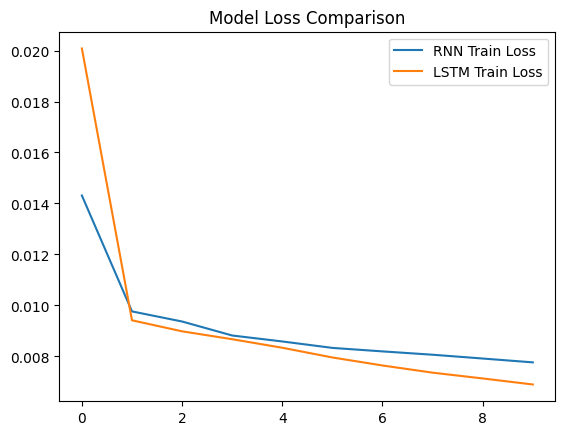

301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


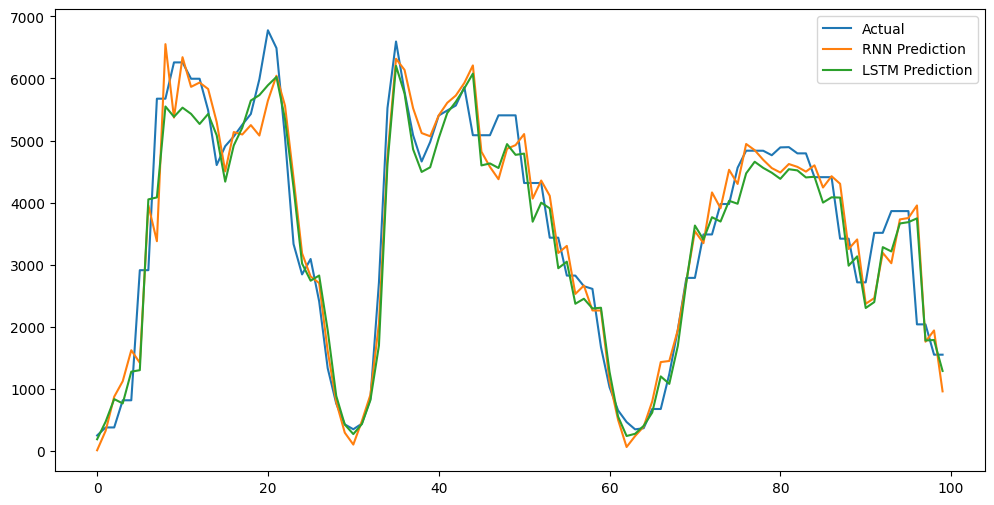

In [6]:
# Plot Loss Curves
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.title('Model Loss Comparison')
plt.legend()
plt.show()

# Predictions
rnn_preds = rnn_model.predict(X_test)
lstm_preds = lstm_model.predict(X_test)

# Plot Predictions (Inverse transform to see actual traffic numbers)
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test[:100]), label='Actual')
plt.plot(scaler.inverse_transform(rnn_preds[:100]), label='RNN Prediction')
plt.plot(scaler.inverse_transform(lstm_preds[:100]), label='LSTM Prediction')
plt.legend()
plt.show()